In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

피클로 생성한 학습 데이터 및 테스트 데이터를 로드

In [2]:
with open('./dataset_0411_train.pkl', 'rb') as train_data:
    train = pickle.load(train_data)
    
with open('./dataset_0411_test.pkl', 'rb') as test_data:
    test = pickle.load(test_data)

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

import numpy as np

In [4]:
def svc_param_selection(X, y, nfolds):
    svm_parameters = [
                        {'kernel': ['rbf'],
                         'gamma': [0.00001,0.0001, 0.001, 0.01, 0.1, 1],
                         'C': [0.01, 0.1, 1, 10, 100, 1000]
                        }
                       ]
    
    clf = GridSearchCV(SVC(), svm_parameters, cv=10)
    clf.fit(X_train, y_train.values.ravel())
    print(clf.best_params_)
    
    return clf

In [5]:
X_train = train[['t-b-s', 'pc_speed']]
y_train = train[['user_id']]
clf = svc_param_selection(X_train, y_train.values.ravel(), 10)

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}


/opt/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


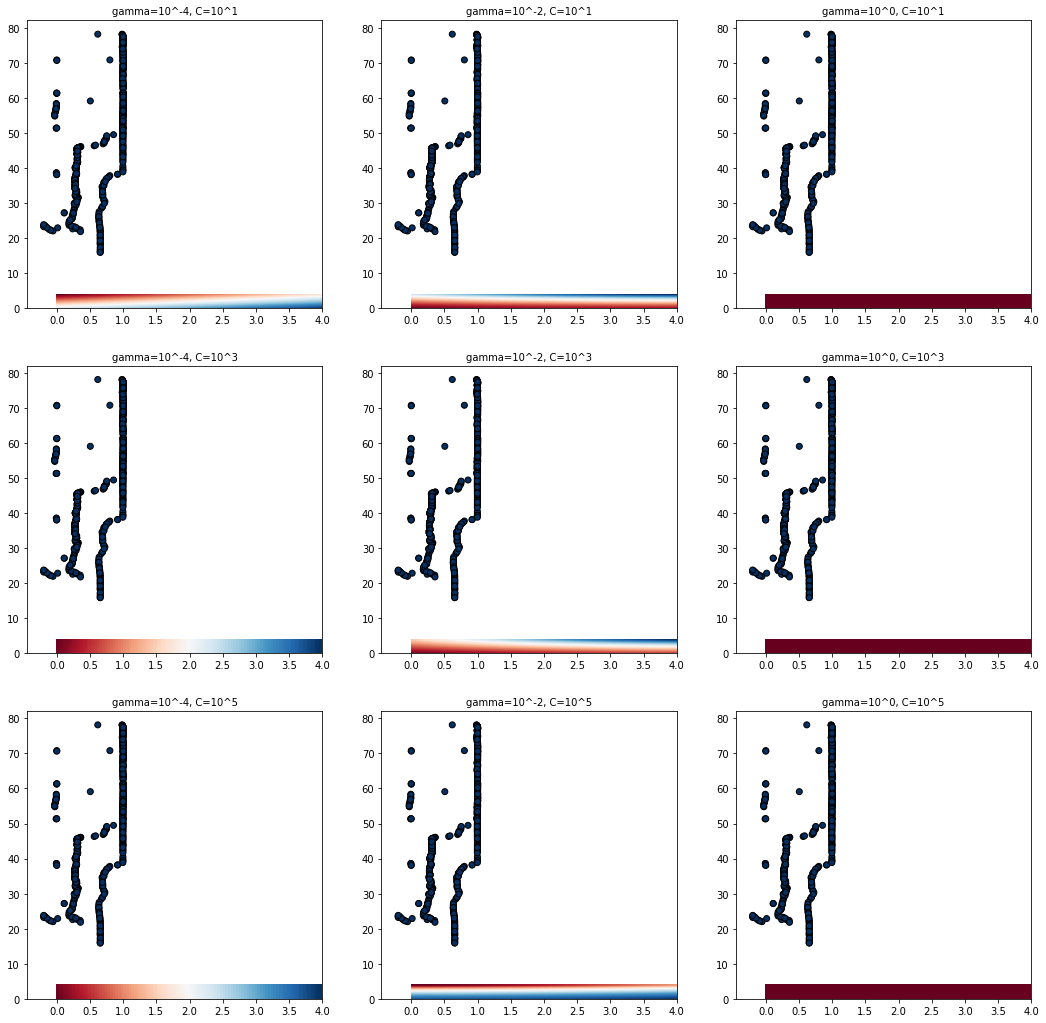

In [6]:
# 시각화를 하기 위해, 최적의 C와 최적의 C를 비교하기 위한 다른 C를 후보로 저장
C_canditates = []
C_canditates.append(clf.best_params_['C'] * 0.01)
C_canditates.append(clf.best_params_['C'])
C_canditates.append(clf.best_params_['C'] * 100)

# 시각화를 하기 위해, 최적의 gamma와 최적의 gamma를 비교하기 위한 다른 gamma를 후보로 저장
gamma_candidates = []
gamma_candidates.append(clf.best_params_['gamma'] * 0.01)
gamma_candidates.append(clf.best_params_['gamma'])
gamma_candidates.append(clf.best_params_['gamma'] * 100)

X = train[['t-b-s', 'pc_speed']]
Y = train['user_id'].tolist()

# 운전자에 해당하는 문자열 0과 1을 벡터화
position = []
for gt in Y:
    if gt == 'C':
        position.append(0)
    else:
        position.append(1)

# 각각의 파라미터에 해당하는 SVM 모델을 만들어 classifiers에 저장
classifiers = []
for C in C_canditates:
    for gamma in gamma_candidates:
        clf = SVC(C=C, gamma=gamma)
        clf.fit(X, Y)
        classifiers.append((C, gamma, clf))

# 18,18 사이즈의 챠트를 구성
plt.figure(figsize=(18, 18))
xx, yy = np.meshgrid(np.linspace(0, 4, 100), np.linspace(0, 4, 100))

# 각각의 모델들에 대한 결정 경계 함수를 적용하여 함께 시각화
for (k, (C, gamma, clf)) in enumerate(classifiers):
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 최적의 모델을 포함한 다른 파라미터로 학습된 모델들을 함께 시각화
    plt.subplot(len(C_canditates), len(gamma_candidates), k + 1)
    plt.title("gamma=10^%d, C=10^%d" % (np.log10(gamma), np.log10(C)),
              size='medium')

    # 서포트 벡터와 결정경계선을 시각화
    plt.pcolormesh(xx, yy, -Z, cmap=plt.cm.RdBu)
    plt.scatter(X['t-b-s'], X['pc_speed'], c=position, cmap=plt.cm.RdBu_r, edgecolors='k')

In [7]:
# 테스트에 사용될 특징을 지정
X_test = test[['t-b-s', 'pc_speed']]

# 특징으로 예측할 값을 지정
y_test = test[['user_id']]

# 최적의 파라미터로 완성된 SVM에 테스트 데이터를 주입
y_true, y_pred = y_test, clf.predict(X_test)

print(classification_report(y_true, y_pred))
print()
print("accuracy : "+ str(accuracy_score(y_true, y_pred)) )

              precision    recall  f1-score   support

           1       0.94      0.98      0.96        81
           2       0.97      0.93      0.95        74

    accuracy                           0.95       155
   macro avg       0.96      0.95      0.95       155
weighted avg       0.96      0.95      0.95       155


accuracy : 0.9548387096774194


In [8]:
# 실제값(ground truth)과 예측값(prediction)이 어느 정도 일치하는지 비교
comparison = pd.DataFrame({'prediction':y_pred, 'ground_truth':y_true.values.ravel()}) 
comparison

,prediction,ground_truth
0,2,2
1,2,2
2,1,2
3,2,2
4,2,2
...,...,...
150,1,1
151,1,1
152,1,1
153,1,1
